In [23]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt

In [24]:
#====================
# Dataset Generation
#====================
np.random.seed(42)

n = 200
X = np.random.uniform(-3 , 3 , n)
true_w , true_b = 2.5 , -1.0
y = true_w * X + true_b + np.random.normal(0 , 2 , n)

In [25]:
def predict(w , b , X):
    return w * X + b

def mse_loss(w , b):
    return np.mean((y - predict(w , b , X)) ** 2)

def full_grad(w , b):
    yhat = predict(w , b , X)
    dw = -2.0 * np.mean(X * (y - yhat))
    db = -2.0 * np.mean(y - yhat)
    return dw , db

def fixed_gd(lr , epochs = 40 , diverge_thresh = 1e6):
    w , b = 0.0 , 0.0
    losses = []
    diverged = False
    for _ in range(epochs):
        dw , db = full_grad(w , b)
        w -= lr * dw
        b -= lr * db
        L = mse_loss(w , b)
        losses.append(L)
        if (not np.isfinite(L)) or (L > diverge_thresh):
            diverged = True
            break
    return w , b , losses , diverged

In [26]:
def backtracking_gd(epochs = 40 , alpha0 = 25.0 , beta = 0.5 , c = 1e-4):
    w , b = 0.0 , 0.0
    losses = []
    accepted_alphas = []
    shrinks = []
    evals = []
    tried_alphas_per_epoch = []

    for _ in range(epochs):
        dw , db = full_grad(w , b)
        grad_norm_sq = dw ** 2 + db ** 2
        current_loss = mse_loss(w , b)

        alpha = alpha0
        k = 0
        tried = [alpha]

        while True:
            new_w = w - alpha * dw
            new_b = b - alpha * db
            new_loss = mse_loss(new_w , new_b)

            if new_loss <= current_loss - c * alpha * grad_norm_sq:
                break

            alpha *= beta
            k += 1
            tried.append(alpha)

            if alpha < 1e-12:
                break

        w , b = new_w , new_b
        losses.append(new_loss)
        accepted_alphas.append(alpha)
        shrinks.append(k)
        evals.append(k + 1)
        tried_alphas_per_epoch.append(tried)

    return w , b , losses , accepted_alphas , shrinks , evals , tried_alphas_per_epoch

In [27]:
#============================
# Run: fixed vs backtracking
#============================
epochs = 40
LR_GOOD = 0.1
LR_BAD  = 0.7

_ , _ , loss_good , div_good = fixed_gd(LR_GOOD , epochs)
_ , _ , loss_bad , div_bad = fixed_gd(LR_BAD , epochs)

ALPHA0 = 25.0
w_bt , b_bt , loss_bt , alphas_bt , shrinks_bt , evals_bt , tried_bt = backtracking_gd(
    epochs = epochs , alpha0 = ALPHA0
)

Text(0.5, 1.0, 'Loss vs Epochs — Full View')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'MSE Loss')

Text(5, 10000.0, 'Diverges quickly')

Text(0.5, 1.0, 'Loss vs Epochs — Zoomed (Stable Region)')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'MSE Loss')

(3.5, 7.0)

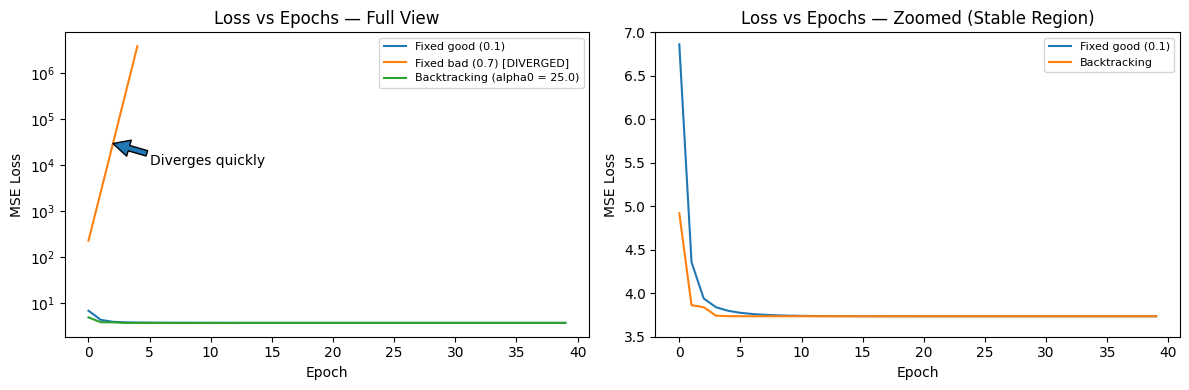

In [28]:
#===============
# Plot 1: Loss
#===============
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))

ax = axes[0]
ax.plot(loss_good , label = f"Fixed good ({LR_GOOD})")
ax.plot(loss_bad , label = f"Fixed bad ({LR_BAD})" + (" [DIVERGED]" if div_bad else ""))
ax.plot(loss_bt , label = f"Backtracking (alpha0 = {ALPHA0})")
ax.set_title("Loss vs Epochs — Full View")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_yscale("symlog" , linthresh = 1)
ax.legend(fontsize = 8)
ax.annotate("Diverges quickly" , xy = (2 , loss_bad[2]) ,
            xytext = (5 , 1e4) , arrowprops = dict())

ax = axes[1]
ax.plot(loss_good , label = f"Fixed good ({LR_GOOD})")
ax.plot(loss_bt , label = "Backtracking")
ax.set_title("Loss vs Epochs — Zoomed (Stable Region)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_ylim(3.5 , 7)
ax.legend(fontsize = 8)

plt.tight_layout()
plt.show()

<Figure size 700x400 with 0 Axes>

Text(0.02, 0.95, 'Note: Fixed LR (0.7) diverged → not plotted')

Text(0.5, 1.0, 'Final Fits — Stable Methods (Clean View)')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

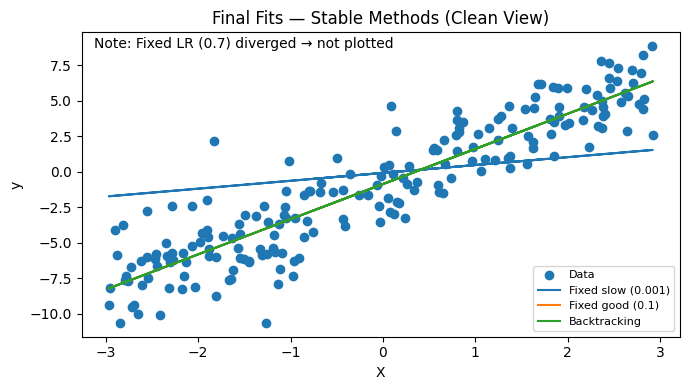

In [29]:
#=====================
# Plot 2: Model fits
#=====================
plt.figure(figsize = (7 , 4))
plt.scatter(X , y , label = "Data")

plt.plot(X , predict(w_slow , b_slow , X) , label = f"Fixed slow ({LR_SLOW})")
plt.plot(X , predict(w_good , b_good , X) , label = f"Fixed good ({LR_GOOD})")
plt.plot(X , predict(w_bt , b_bt , X) , label = "Backtracking")

plt.text(0.02 , 0.95 , f"Note: Fixed LR ({LR_BAD}) diverged → not plotted" ,
         transform = plt.gca().transAxes)

plt.title("Final Fits — Stable Methods (Clean View)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend(fontsize = 8)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Backtracking: Accepted alpha per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'alpha')

Text(0.5, 1.0, 'Backtracking Effort per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'count')

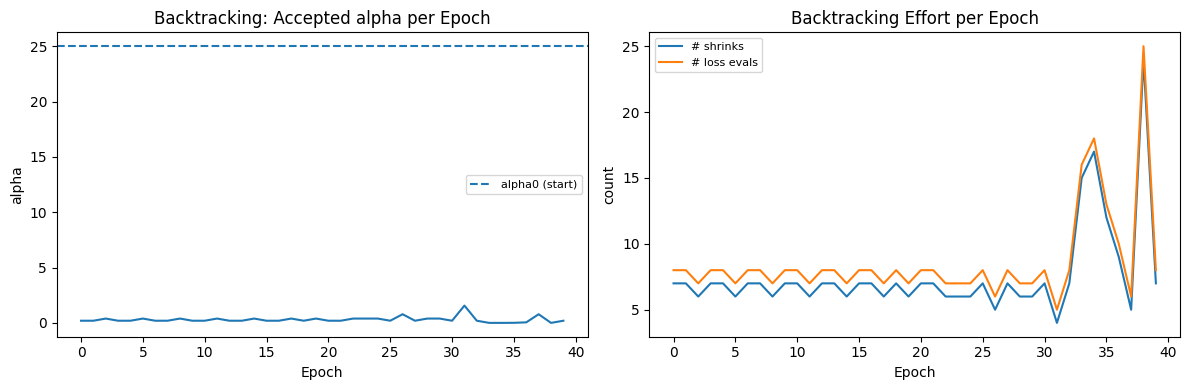

In [30]:
#=================================
# Plot 3: Backtracking internals
#=================================
fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))

ax = axes[0]
ax.plot(alphas_bt)
ax.axhline(ALPHA0 , linestyle = "--" , label = "alpha0 (start)")
ax.set_title("Backtracking: Accepted alpha per Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("alpha")
ax.legend(fontsize = 8)

ax = axes[1]
ax.plot(shrinks_bt , label = "# shrinks")
ax.plot(evals_bt , label = "# loss evals")
ax.set_title("Backtracking Effort per Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("count")
ax.legend(fontsize = 8)

plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

Text(0.5, 1.0, 'Backtracking all tried Step Sizes per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'alpha tried (log scale)')

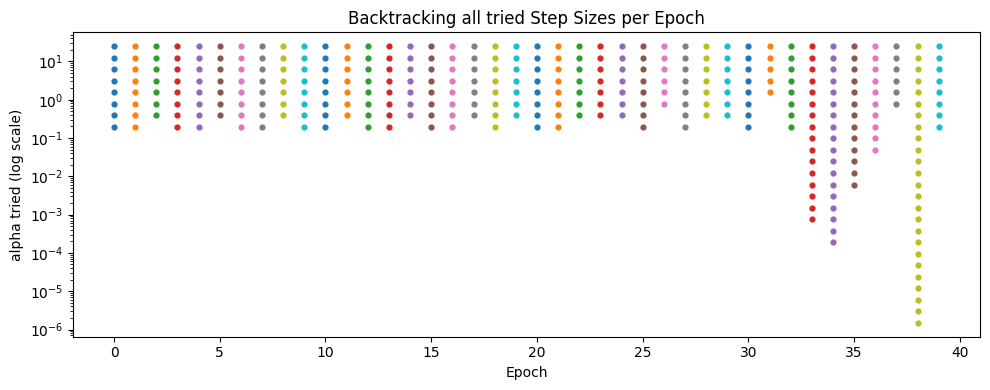

In [31]:
#=================================
# Plot 4: Alphas tried each epoch
#=================================
plt.figure(figsize = (10 , 4))
for epoch , tried in enumerate(tried_bt):
    plt.scatter([epoch] * len(tried) , tried , s = 12)

plt.yscale("log")
plt.title("Backtracking all tried Step Sizes per Epoch")
plt.xlabel("Epoch")
plt.ylabel("alpha tried (log scale)")
plt.tight_layout()
plt.show()

In [32]:
print(f"Backtracking final loss: {loss_bt[-1]:.4f}")
print(f"Backtracking avg accepted alpha: {np.mean(alphas_bt):.4f}")
print(f"Max shrinks in an epoch: {np.max(shrinks_bt)}")

Backtracking final loss: 3.7353
Backtracking avg accepted alpha: 0.2944
Max shrinks in an epoch: 24
